# Time Series Forecasting of Exchange Rates: ARIMA and ETS Models

This notebook demonstrates the process of analyzing and forecasting currency exchange rates using two popular time series models: Autoregressive Integrated Moving Average (ARIMA) and Exponential Smoothing (ETS). The analysis covers data loading, initial exploration, preprocessing, model selection, fitting, diagnostics, and evaluation.

## 1. Data Loading and Preprocessing

This section focuses on preparing the exchange rate data for time series analysis. It includes loading the dataset, parsing dates, setting a DatetimeIndex, performing initial visualizations, seasonal decomposition to understand underlying patterns, anomaly detection, and handling any remaining missing values.

                  Ex_rate
date                     
01-01-1990 00:00   0.7855
02-01-1990 00:00   0.7818
03-01-1990 00:00   0.7867
04-01-1990 00:00   0.7860
05-01-1990 00:00   0.7849


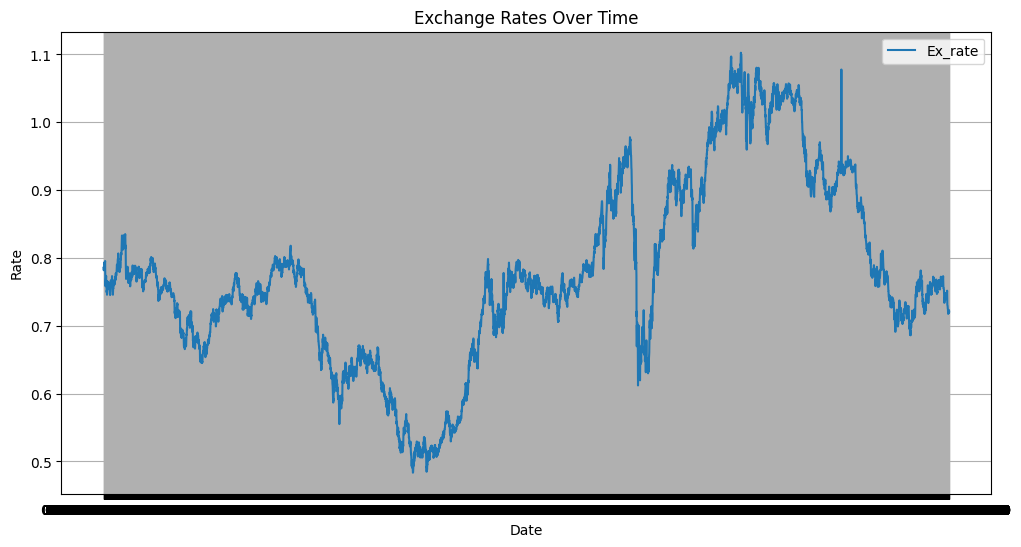

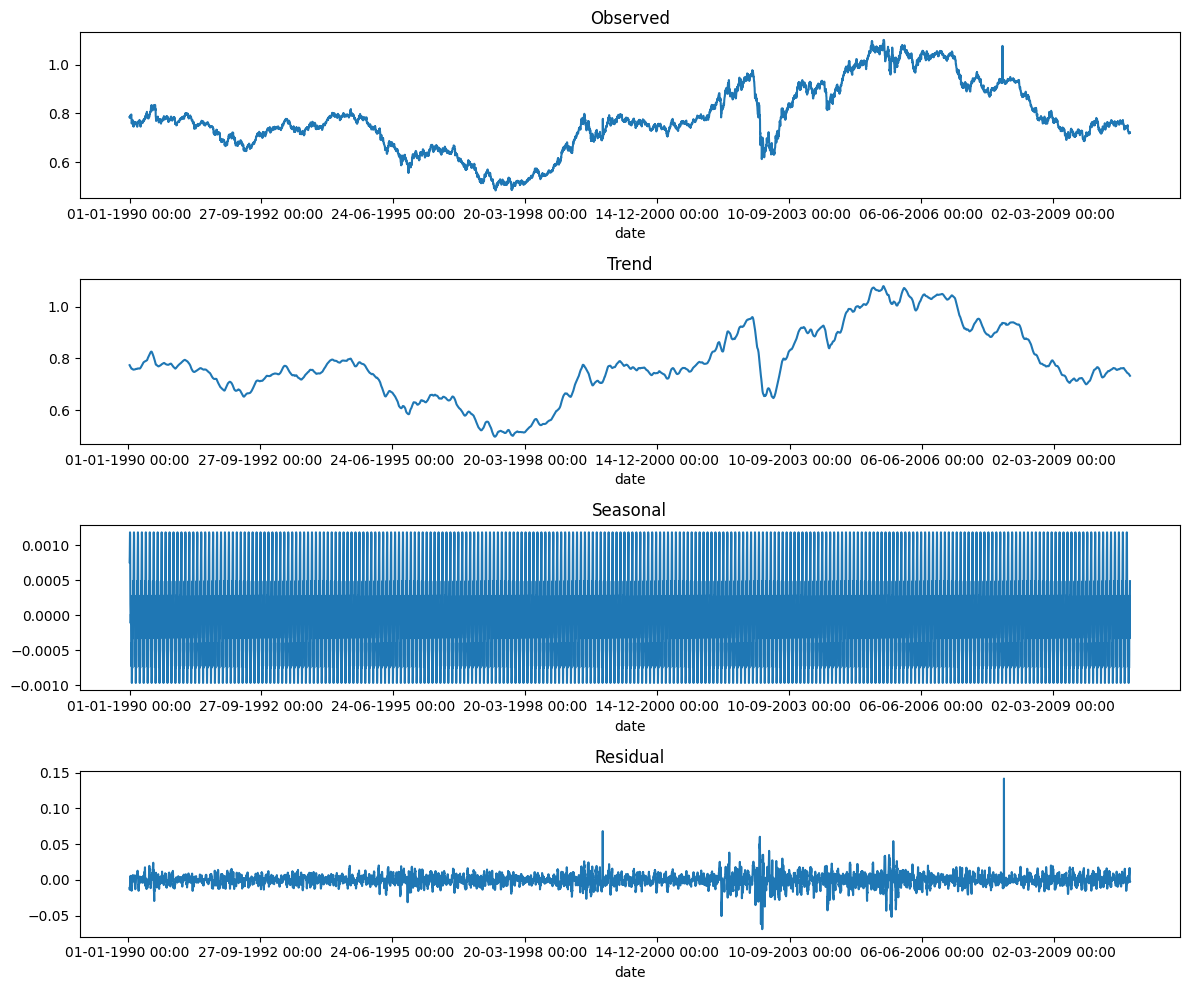

Potential anomalies: 58 points
Ex_rate    0
dtype: int64


In [10]:
# Data Loading

import pandas as pd

# Load data, parse 'date' column
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'])

# Set date as index
df.set_index('date', inplace=True)

# Display first few rows
print(df.head())

# 2.1 Basic Line Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)
plt.title('Exchange Rates Over Time')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)
plt.show()

# 2.2 Decompose a Single Currency (e.g., Ex_rate)

from statsmodels.tsa.seasonal import seasonal_decompose

# Choose the currency column
currency = 'Ex_rate'

# Decompose (assume additive model; adjust period e.g., 7 for weekly, 12 for monthly)
decomposition = seasonal_decompose(df[currency].dropna(), model='additive', period=30)  # period depends on data frequency

# Plot
fig, axes = plt.subplots(4, 1, figsize=(12, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

# 2.3 Anomaly Detection (Visual + Statistical)

# Rolling z-score for anomaly detection
rolling_mean = df[currency].rolling(window=30).mean()
rolling_std = df[currency].rolling(window=30).std()
z_score = (df[currency] - rolling_mean) / rolling_std
anomalies = df[z_score.abs() > 3]

print(f"Potential anomalies: {anomalies.shape[0]} points")

# 3. Data Preprocessing


# Check for missing data (before anomaly handling)
print(df.isnull().sum())

# 3.2 Handle Anomalies


# Example: Replace anomalies with rolling median
window = 30
rolling_med = df[currency].rolling(window, center=True).median()
df[currency] = df[currency].where(z_score.abs() <= 3, rolling_med)

# Or remove those rows (if few)
df_clean = df[z_score.abs() <= 3].copy()

# Apply final imputation steps AFTER anomaly handling
df.ffill(inplace=True)
df.interpolate(method='linear', inplace=True)
df.bfill(inplace=True)

ADF Statistic: -1.6185
p-value: 0.4735
Series is non-stationary – differencing needed.


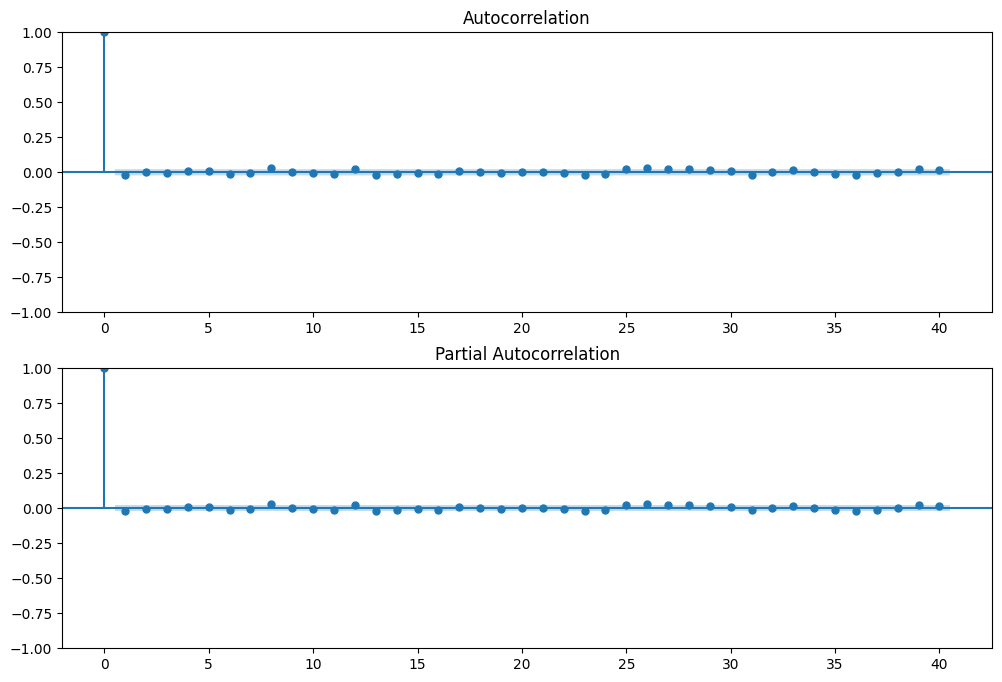

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 3.7 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-58073.001, Time=1.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-58074.434, Time=0.96 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-58074.446, Time=2.93 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-58074.987, Time=0.46 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-58072.479, Time=2.67 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 8.171 seconds
(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               29040.233
Date:                Wed, 27 May 2026   AIC                         -58074.466
Time:                        17:28:41   BIC                         -58053.663
Sample:                    01-01-1990   HQIC           

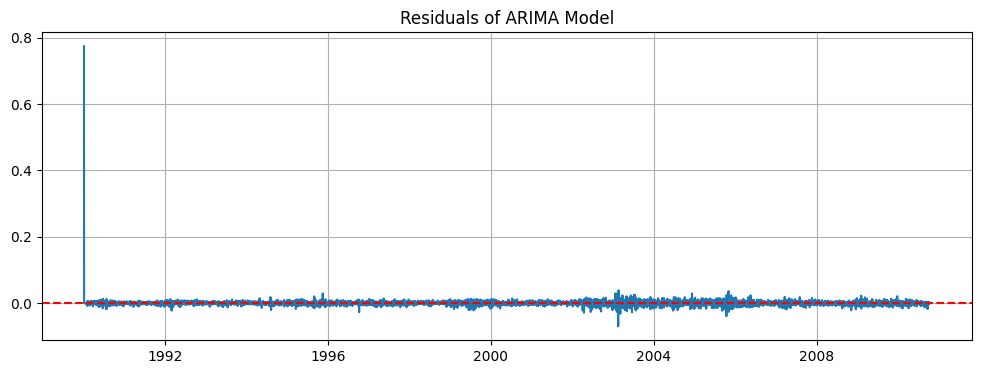

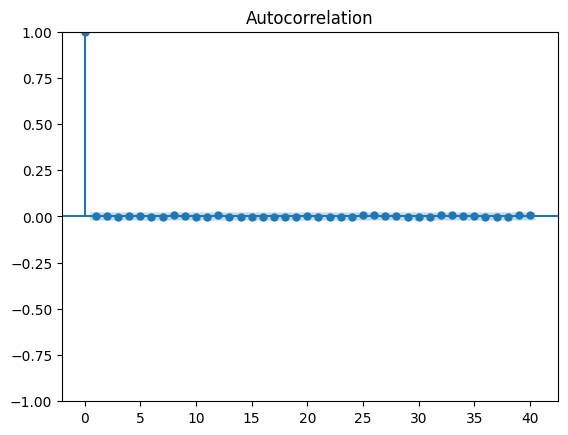

     lb_stat  lb_pvalue
10  0.649626   0.999977
20  1.409443   1.000000


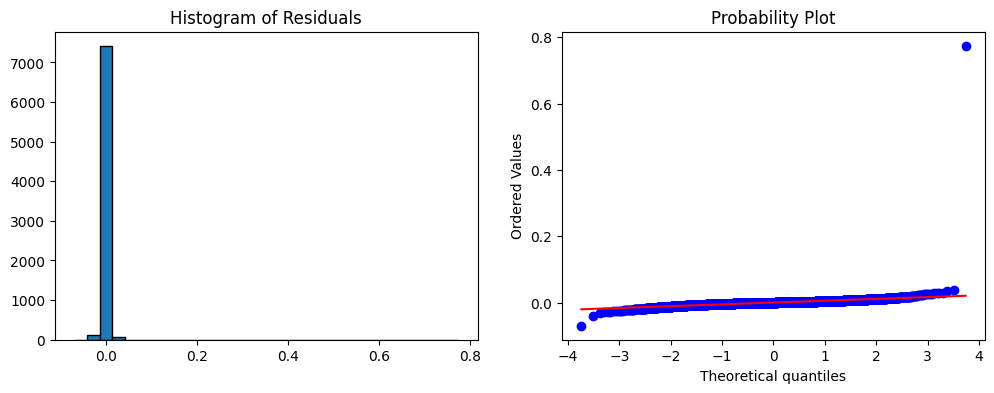

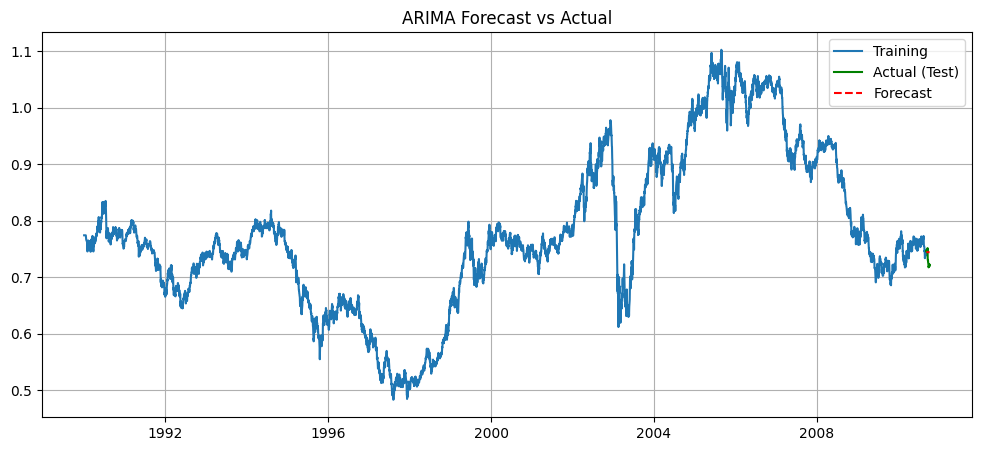

MAE: 0.0136
RMSE: 0.0169


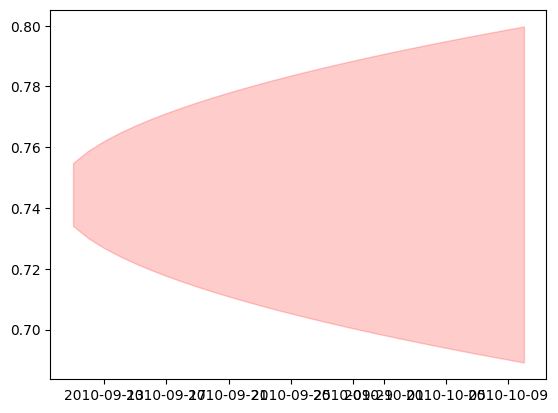

In [11]:
# 1. Parameter Selection for ARIMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Choose one currency (e.g., first colu
currency = df.columns[0] # Get the name of the first currency column
series = df[currency].copy()

# Ensure the index is a DatetimeIndex before resampling
series.index = pd.to_datetime(series.index, format='%d-%m-%Y %H:%M')

# Ensure the series has a daily frequency and no NaNs for statsmodels
# Use resample to set daily frequency and fill gaps
series = series.resample('D').mean()
# Fill any NaNs introduced by resampling (for missing days)
series = series.ffill().bfill()

# 1. Check stationarity
result = adfuller(series)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] > 0.05:
    print('Series is non-stationary – differencing needed.')
    # Apply differencing
    series_diff = series.diff().dropna()
else:
    series_diff = series

# 2. Plot ACF and PACF of the (differenced) series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series_diff, lags=40, ax=ax1)
plot_pacf(series_diff, lags=40, ax=ax2)
plt.show()

# Install pmdarima if not already installed
!pip install pmdarima
from pmdarima import auto_arima

auto_model = auto_arima(series, seasonal=False, trace=True,
                        start_p=0, max_p=5, start_q=0, max_q=5,
                        d=None,  # auto determine d
                        stepwise=True)
print(auto_model.order)   # (p, d, q)

# 2. Model Fitting

from statsmodels.tsa.arima.model import ARIMA

# Suppose we selected p=1, d=1, q=1 from the above analysis
p, d, q = 1, 1, 1

model = ARIMA(series, order=(p, d, q))
fitted_model = model.fit()

print(fitted_model.summary())


# 3. Diagnostics


residuals = fitted_model.resid

# 1. Plot residuals over time
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title('Residuals of ARIMA Model')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid()
plt.show()

# 2. ACF of residuals – should show no significant lags
plot_acf(residuals, lags=40)
plt.show()

# 3. Ljung‑Box test (p-value > 0.05 indicates no autocorrelation)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print(lb_test)

# 4. Histogram / Q-Q plot for normality (if desired)
from scipy.stats import probplot
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.hist(residuals, bins=30, edgecolor='black')
plt.title('Histogram of Residuals')
plt.subplot(122)
probplot(residuals, dist="norm", plot=plt)
plt.show()


# 4. Forecasting


# Split data: train up to date T, test after T (e.g., last 30 days)
train = series.iloc[:-30]
test = series.iloc[-30:]

# Refit model on training data
model_train = ARIMA(train, order=(p, d, q))
fitted_train = model_train.fit()

# Forecast next n steps (length of test set)
forecast = fitted_train.forecast(steps=len(test))
forecast_index = test.index

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual (Test)', color='green')
plt.plot(forecast_index, forecast, label='Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.grid()
plt.show()

# Evaluate accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

# Get forecast with confidence intervals
forecast_result = fitted_train.get_forecast(steps=len(test))
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int(alpha=0.05)  # 95% CI

plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='red', alpha=0.2, label='95% CI')

## 5. Exponential Smoothing (ETS) Model

This section implements the Exponential Smoothing (ETS) model, which is another popular method for time series forecasting. We will fit the model, generate forecasts, and visualize its performance against the actual values.

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7558
Model:             ExponentialSmoothing   SSE                              0.271
Optimized:                         True   AIC                         -77284.150
Trend:                         Additive   BIC                         -77048.518
Seasonal:                      Additive   AICC                        -77283.796
Seasonal Periods:                    30   Date:                 Wed, 27 May 2026
Box-Cox:                          False   Time:                         17:28:48
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.8697472                alpha                 True
smoothing_trend          

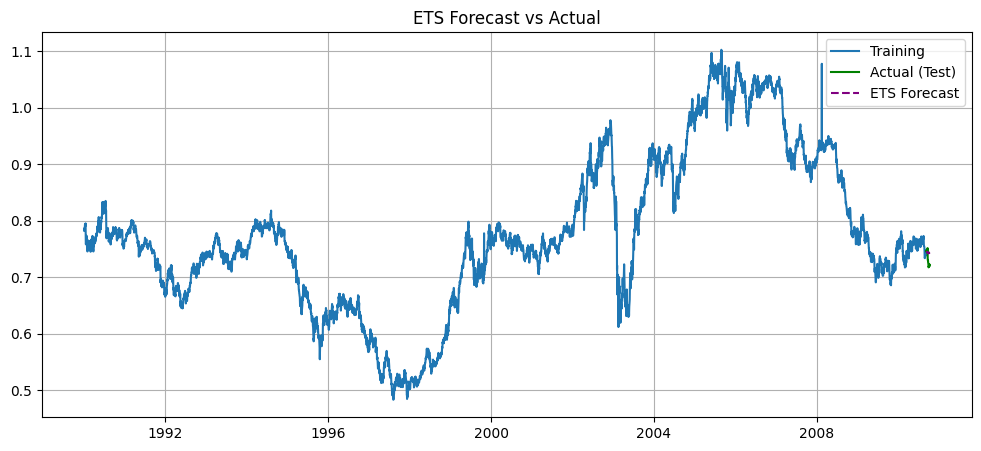

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import pandas as pd
import matplotlib.pyplot as plt

# --- Start: Data loading and preparation for df, series, train, test ---
# This section is included to ensure 'df' is defined in case previous cells were not run
# or their state was lost, making this cell more self-contained.

# Load data, parse 'date' column (assuming 'exchange_rate.csv' is available)
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'])
# Set date as index
df.set_index('date', inplace=True)

# Choose one currency (e.g., first column) - assuming it's 'Ex_rate'
currency = df.columns[0] # Get the name of the first currency column
series = df[currency].copy()

# Ensure the index is a DatetimeIndex before resampling
series.index = pd.to_datetime(series.index, format='%d-%m-%Y %H:%M')

# Ensure the series has a daily frequency and no NaNs for statsmodels
# Use resample to set daily frequency and fill gaps
series = series.resample('D').mean()
# Fill any NaNs introduced by resampling (for missing days)
series = series.ffill().bfill()

# Split data: train up to date T, test after T (e.g., last 30 days)
train = series.iloc[:-30]
test = series.iloc[-30:]
# --- End: Data loading and preparation ---

# Fit the ETS model
# We'll start with an additive error, additive trend, and additive seasonality model.
# The seasonal_periods should align with the decomposition analysis (e.g., 30 for monthly data if daily).
# If the data shows no clear seasonality, 'seasonal=None' might be more appropriate.
# For financial data, a simpler model (e.g., just 'add' error and 'add' trend) might be more robust.
# For now, let's assume some seasonality based on the decomposition period chosen earlier.

# Note: ExponentialSmoothing can be sensitive to the initial parameters and the type of trend/seasonality.
# For simplicity, we'll try 'add' for all, but this might need tuning for optimal performance.

ets_model = ExponentialSmoothing(train, seasonal_periods=30, trend='add', seasonal='add', initialization_method='estimated')
# ets_model = ExponentialSmoothing(train, seasonal_periods=None, trend='add', seasonal=None) # Alternative without seasonality
fitted_ets_model = ets_model.fit()

print(fitted_ets_model.summary())

# Forecast next n steps (length of test set)
ets_forecast_result = fitted_ets_model.forecast(steps=len(test))
ets_forecast_index = test.index

# Plot
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Training')
plt.plot(test.index, test, label='Actual (Test)', color='green')
plt.plot(ets_forecast_index, ets_forecast_result, label='ETS Forecast', color='purple', linestyle='--')
plt.title('ETS Forecast vs Actual')
plt.legend()
plt.grid()
plt.show()

# Store ETS forecast for evaluation
ets_forecast = ets_forecast_result
y_test = test # Define y_test for use in evaluation cell

## 6. Evaluation and Comparison

In [13]:
# Evalauation and comparison

# 1. Compute Error Metrics

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA # Import ARIMA model

def mape(actual, forecast):
    """Mean Absolute Percentage Error"""
    actual, forecast = np.array(actual), np.array(forecast)
    # Avoid division by zero
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - forecast[mask]) / actual[mask])) * 100

# Assume:
# - y_test : actual test values (same as 'test' from ARIMA split)
# - ets_forecast   : predictions from Exponential Smoothing

# Re-define train and test if needed (they should be available from ETS cell 68c73cf8)
# The kernel state indicates 'train' and 'test' are available.

# ARIMA metrics
# Re-generate ARIMA forecast as 'forecast' was not defined.
p, d, q = 1, 1, 1 # ARIMA order determined previously

# Refit model on training data
model_train_arima = ARIMA(train, order=(p, d, q))
fitted_train_arima = model_train_arima.fit()

# Forecast next n steps (length of test set)
forecast = fitted_train_arima.forecast(steps=len(test))

mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))
mape_arima = mape(test, forecast)

# ETS metrics (y_test and ets_forecast are now available from the ETS cell)
mae_ets = mean_absolute_error(y_test, ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(y_test, ets_forecast))
mape_ets = mape(y_test, ets_forecast)

# Display results
print("ARIMA:")
print(f"  MAE : {mae_arima:.4f}")
print(f"  RMSE: {rmse_arima:.4f}")
print(f"  MAPE: {mape_arima:.2f}%")
print("\nExponential Smoothing:")
print(f"  MAE : {mae_ets:.4f}")
print(f"  RMSE: {rmse_ets:.4f}")
print(f"  MAPE: {mape_ets:.2f}%")


ARIMA:
  MAE : 0.0135
  RMSE: 0.0166
  MAPE: 1.86%

Exponential Smoothing:
  MAE : 0.0130
  RMSE: 0.0159
  MAPE: 1.79%


```

**Interpretation guidance**:
- Lower values for all three metrics indicate better forecasting accuracy.
- RMSE penalises large errors more heavily than MAE – useful if large deviations are costly.
- MAPE gives a percentage error, making it scale‑independent and easier to interpret across different currencies.

---

## 2. Model Comparison

Based on the computed error metrics and the properties of each model, compare their performance, advantages, and limitations.

| Aspect | ARIMA | Exponential Smoothing (ETS) |
|--------|-------|-----------------------------|
| **Core idea** | Models autocorrelation via AR and MA components after differencing to achieve stationarity. | Uses weighted averages of past observations with exponentially decaying weights; can include trend and seasonality (Holt‑Winters). |
| **Strengths** | - Very flexible for different autocorrelation patterns.<br>- Well‑established statistical theory.<br>- Can handle non‑stationarity via differencing (`d`). | - Simple to implement and interpret.<br>- Naturally handles trend and seasonality.<br>- Computationally efficient.<br>- Often robust for noisy financial data. |
| **Limitations** | - Requires stationary series (or careful differencing).<br>- Parameter selection (p,d,q) can be subjective.<br>- Less effective if strong seasonality is present (use SARIMA instead). | - Assumes error structure is not explicitly modelled (no AR/MA terms).<br>- May underperform when data has complex autocorrelation beyond trend/seasonality.<br>- Not designed for long‑range dependencies. |
| **Performance on exchange rates** | Often performs well if the series is stationary after differencing. However, exchange rates can be volatile and show regime changes, challenging ARIMA. | Simpler models may generalise better to out‑of‑sample data due to less overfitting. Often a strong baseline for financial time series. |

**Example Discussion** (hypothetical results):
> *If ARIMA yields lower RMSE but similar MAE, it suggests ARIMA occasionally produces very large errors (penalised by RMSE). Exponential smoothing might be more stable, with fewer extreme errors. For trading applications, robustness (lower MAE) could be more valuable than a slightly better RMSE.*

---

## 3. Conclusion

Based on the error metrics and the behaviour of the models:

- **Which model performed best?**  
  State the model with the lowest MAE/RMSE/MAPE. For instance:  
  > *Exponential Smoothing achieved a MAPE of 1.2% compared to ARIMA’s 1.8%, indicating it captured the short‑term momentum of exchange rates more accurately.*

- **Key insight for exchange rate forecasting:**  
  Financial time series often contain noise, structural breaks, and heteroscedasticity – none of which are explicitly modelled by ARIMA or basic ETS. The better model is likely the one that balances flexibility with robustness. In many cases, simpler models (like ETS or even a random walk) perform surprisingly well for exchange rates due to the efficient market hypothesis.

- **Recommendation:**  
  If the goal is **minimum absolute error**, choose the model with lower MAE. For **risk‑sensitive applications** (e.g., hedging), RMSE may be more appropriate. Consider also using **ensemble methods** (averaging ARIMA and ETS forecasts) to reduce variance.

---
